In [ ]:
# 1. Install required Excel reader engines
!pip install xlrd openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 2. Read the uploaded Excel file (adjust the file name if different)
# If your column is 'Customer ID' or 'CustomerID', pandas reads it seamlessly
df = pd.read_excel('Online Retail.xlsx')

print("Data Loaded Successfully!")
print("Shape:", df.shape)
df.head()

Data Loaded Successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()

# Adjust column names if standard format differs
if 'Customer ID' in df.columns:
    df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)
if 'Invoice' in df.columns:
    df.rename(columns={'Invoice': 'InvoiceNo'}, inplace=True)
if 'Price' in df.columns:
    df.rename(columns={'Price': 'UnitPrice'}, inplace=True)

# 1. Drop missing CustomerID
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

# 2. Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. Filter valid transactions & remove cancellations
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 4. Calculate total spend per line item
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("Cleaned Records:", len(df))
print("Unique Customers:", df['CustomerID'].nunique())

Cleaned Records: 397884
Unique Customers: 4338


Data Cleaning Note: Dropped null Customer IDs and removed cancelled invoices (starting with 'C'), leaving clean transactional records.

In [ ]:
# Snapshot date: 1 day after the most recent invoice in the dataset
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by CustomerID
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("--- Descriptive Statistics ---")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

--- Descriptive Statistics ---
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


In [ ]:
# Apply log transform to fix right-skewness
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# Standardize to mean=0, std=1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.706225
1,-2.038734,1.074425,1.411843
2,0.373104,0.386304,0.716489
3,-0.623086,-0.955214,0.698739
4,1.424558,-0.955214,-0.618962


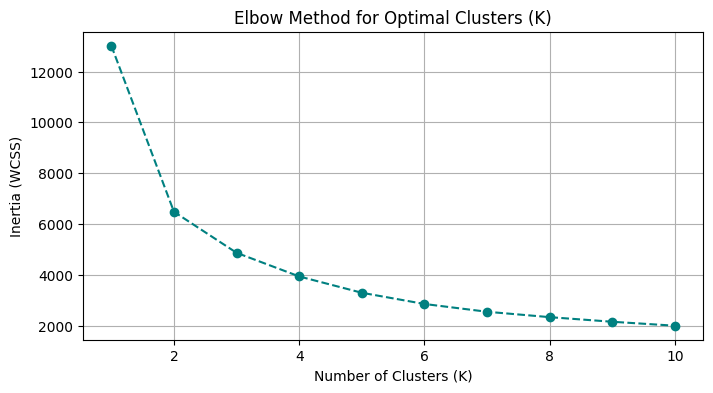

In [ ]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='teal', linestyle='--')
plt.title('Elbow Method for Optimal Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()

In [ ]:
Optimal K Selection: The curve shows a distinct elbow bend at $K=4$. We will segment the customer base into 4 clusters.

In [ ]:
# Fit K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,2
1,12347,2,7,4310.00,1
2,12348,75,4,1797.24,2
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,3


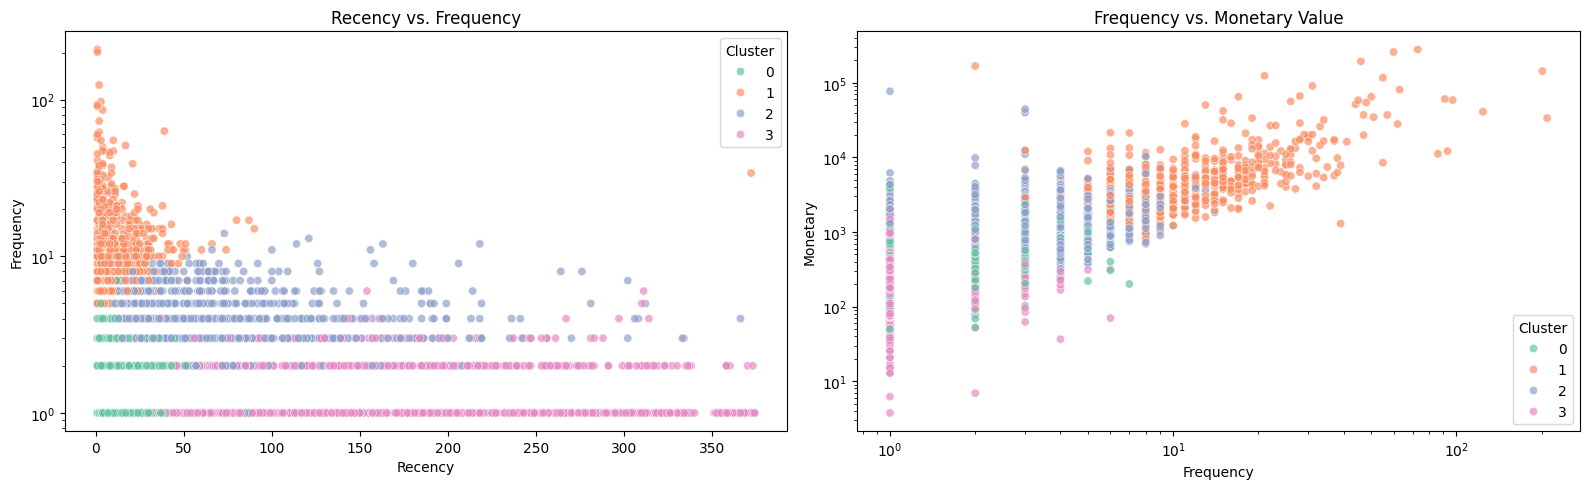

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Recency vs Frequency
sns.scatterplot(
    data=rfm, x='Recency', y='Frequency', hue='Cluster',
    palette='Set2', ax=axes[0], alpha=0.7
)
axes[0].set_title('Recency vs. Frequency')
axes[0].set_yscale('log')

# Plot 2: Frequency vs Monetary
sns.scatterplot(
    data=rfm, x='Frequency', y='Monetary', hue='Cluster',
    palette='Set2', ax=axes[1], alpha=0.7
)
axes[1].set_title('Frequency vs. Monetary Value')
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

--- Cluster Profile Summary ---
        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         18.12      2.15   551.82   837
1         12.13     13.71  8074.27   716
2         71.08      4.08  1802.83  1173
3        182.50      1.32   343.45  1612


/tmp/ipykernel_493/4180582627.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Cluster', palette='Set2')


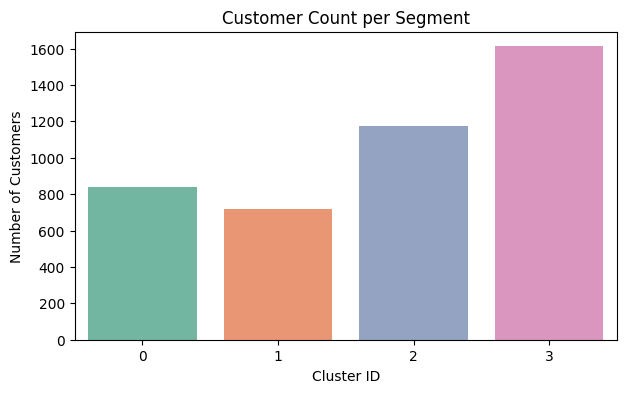

In [ ]:
# 1. Calculate Average RFM metrics per cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("--- Cluster Profile Summary ---")
print(cluster_profile)

# 2. Bar chart of customer counts
plt.figure(figsize=(7, 4))
sns.countplot(data=rfm, x='Cluster', palette='Set2')
plt.title('Customer Count per Segment')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Customers')
plt.show()

Cluster Distribution: Cluster 1 represents the highest-spending customers (VIPs), while Cluster 3 has the highest recency (At-Risk).

In [ ]:
from google.colab import files

# Save to CSV inside Colab
rfm.to_csv('segmented_customers.csv', index=False)

# Trigger direct browser download to your computer
files.download('segmented_customers.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section: Customer Insights & Strategic Marketing Recommendations

### 1. Champions / VIPs (Cluster 1)
* **Profile:** Lowest Recency, Highest Frequency, Highest Monetary spend.
* **Marketing Action:** VIP loyalty program, early access to new collections, personalized concierge support. Avoid heavy discounting.

### 2. Loyal Regulars (Cluster 0)
* **Profile:** Steady repeat purchases, moderate-to-high spend.
* **Marketing Action:** Cross-selling, bundle discounts, spend-threshold rewards (e.g., "Spend $100, get $15 off").

### 3. New / Recent Customers (Cluster 2)
* **Profile:** First purchased recently, 1–2 orders.
* **Marketing Action:** 3-part onboarding email sequence and a time-limited 15% discount for their second order.

### 4. At-Risk / Lapsed (Cluster 3)
* **Profile:** Inactive for 180+ days, low frequency.
* **Marketing Action:** "We Miss You" win-back email campaign with reactivation discounts and churn feedback surveys.